In [1]:
import h5py
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import plotly.express as px

import matplotlib.pyplot as plt
from src import io, vis, timesync
import xarray as xr
from src.plots import plot_PSTH
from src.plots import *
from src.xarray_ops import stack_epochs

In [2]:
# set raw and processed_paths
# define experiment id
exp_id = 'TSeries_20251217-101'

raw_path = io.get_base_path(exp_id,'raw')
processed_path = io.get_base_path(exp_id, 'processed')
print(raw_path)

/Volumes/AhmedLab/princess/data/raw/TSeries_20251217-101


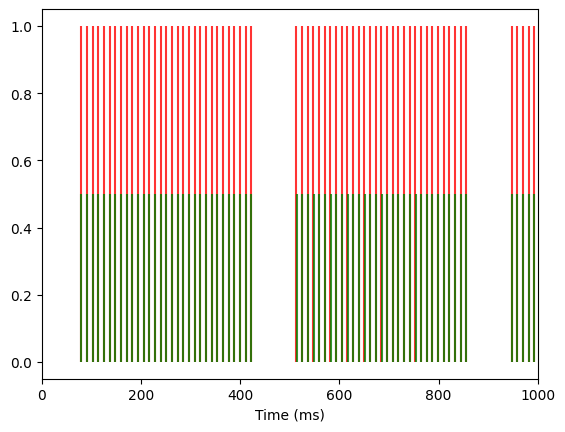

In [3]:
# load in scope timestamp data
scope_timestamps = timesync.extract_scope_timestamps(raw_path, plot=True)

# load in calcium and spatial data
cluster_labels, signal = io.load_clusters(processed_path)
scope_fr, camera_fr, brain_dim = io.load_acquisition_params(processed_path)

In [4]:
print(brain_dim)


[ 256  170   31 2767]


In [5]:
def calculate_volume_and_slice_rate(timestamps_dataframe, slices_per_vol):
    array = np.array(timestamps_dataframe[0])
    total_exp_length = array[-1] /1000 # length of experiment in seconds
    slice_rate = len(array) / total_exp_length
    volume_rate = (len(array)/slices_per_vol) / total_exp_length

    print(f'Imaging at a slice rate of {slice_rate}Hz and volume rate of {volume_rate}Hz')

calculate_volume_and_slice_rate(scope_timestamps, brain_dim[2])

Imaging at a slice rate of 71.46982638448824Hz and volume rate of 2.3054782704673626Hz


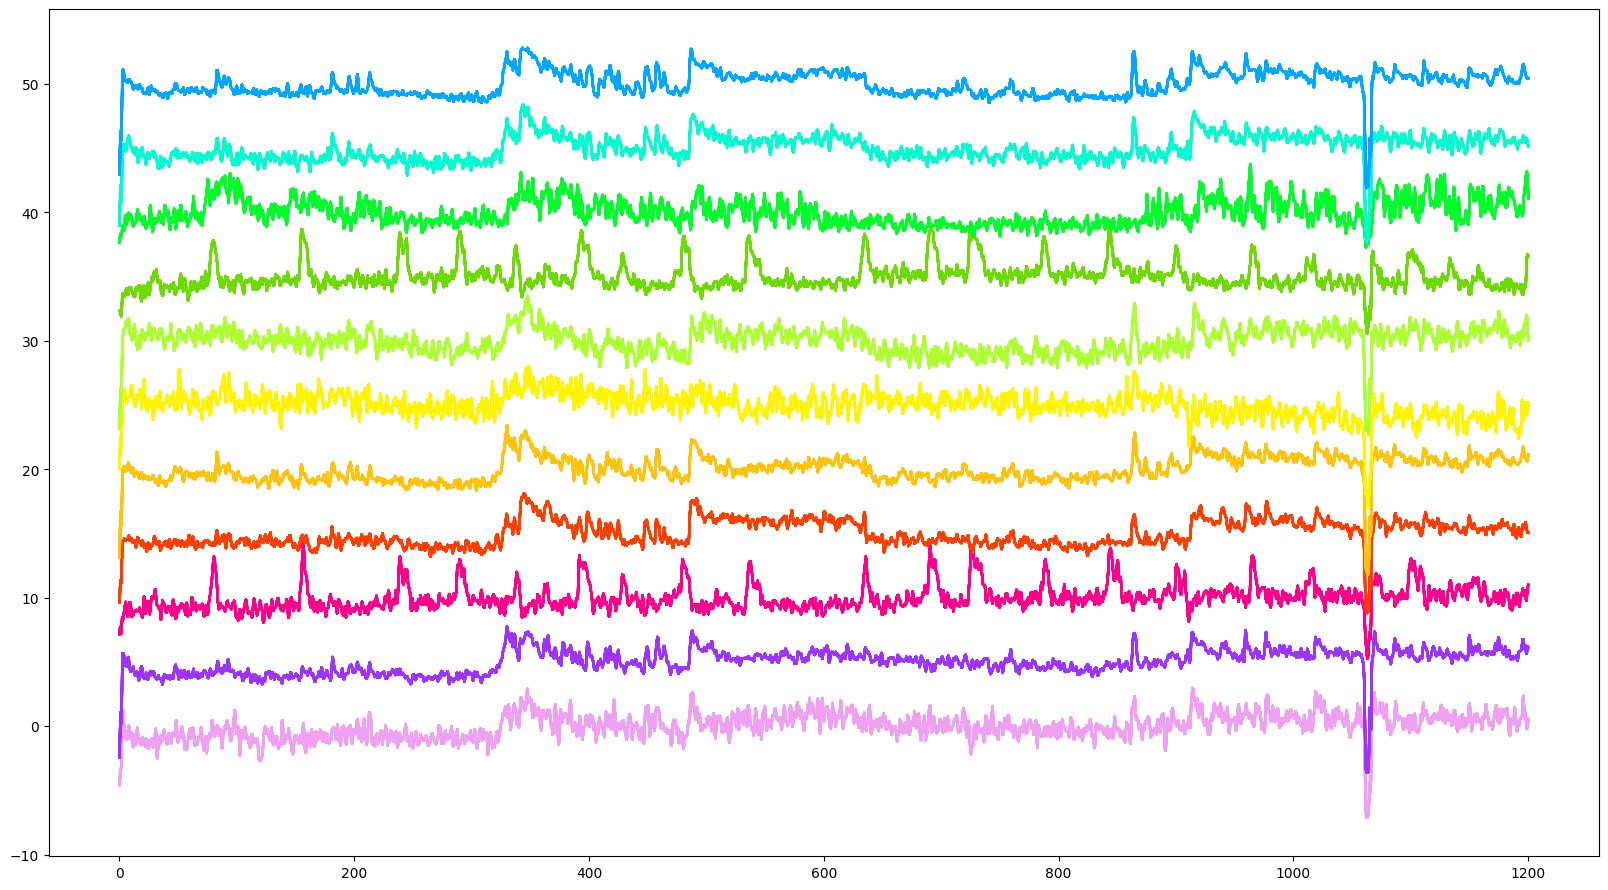

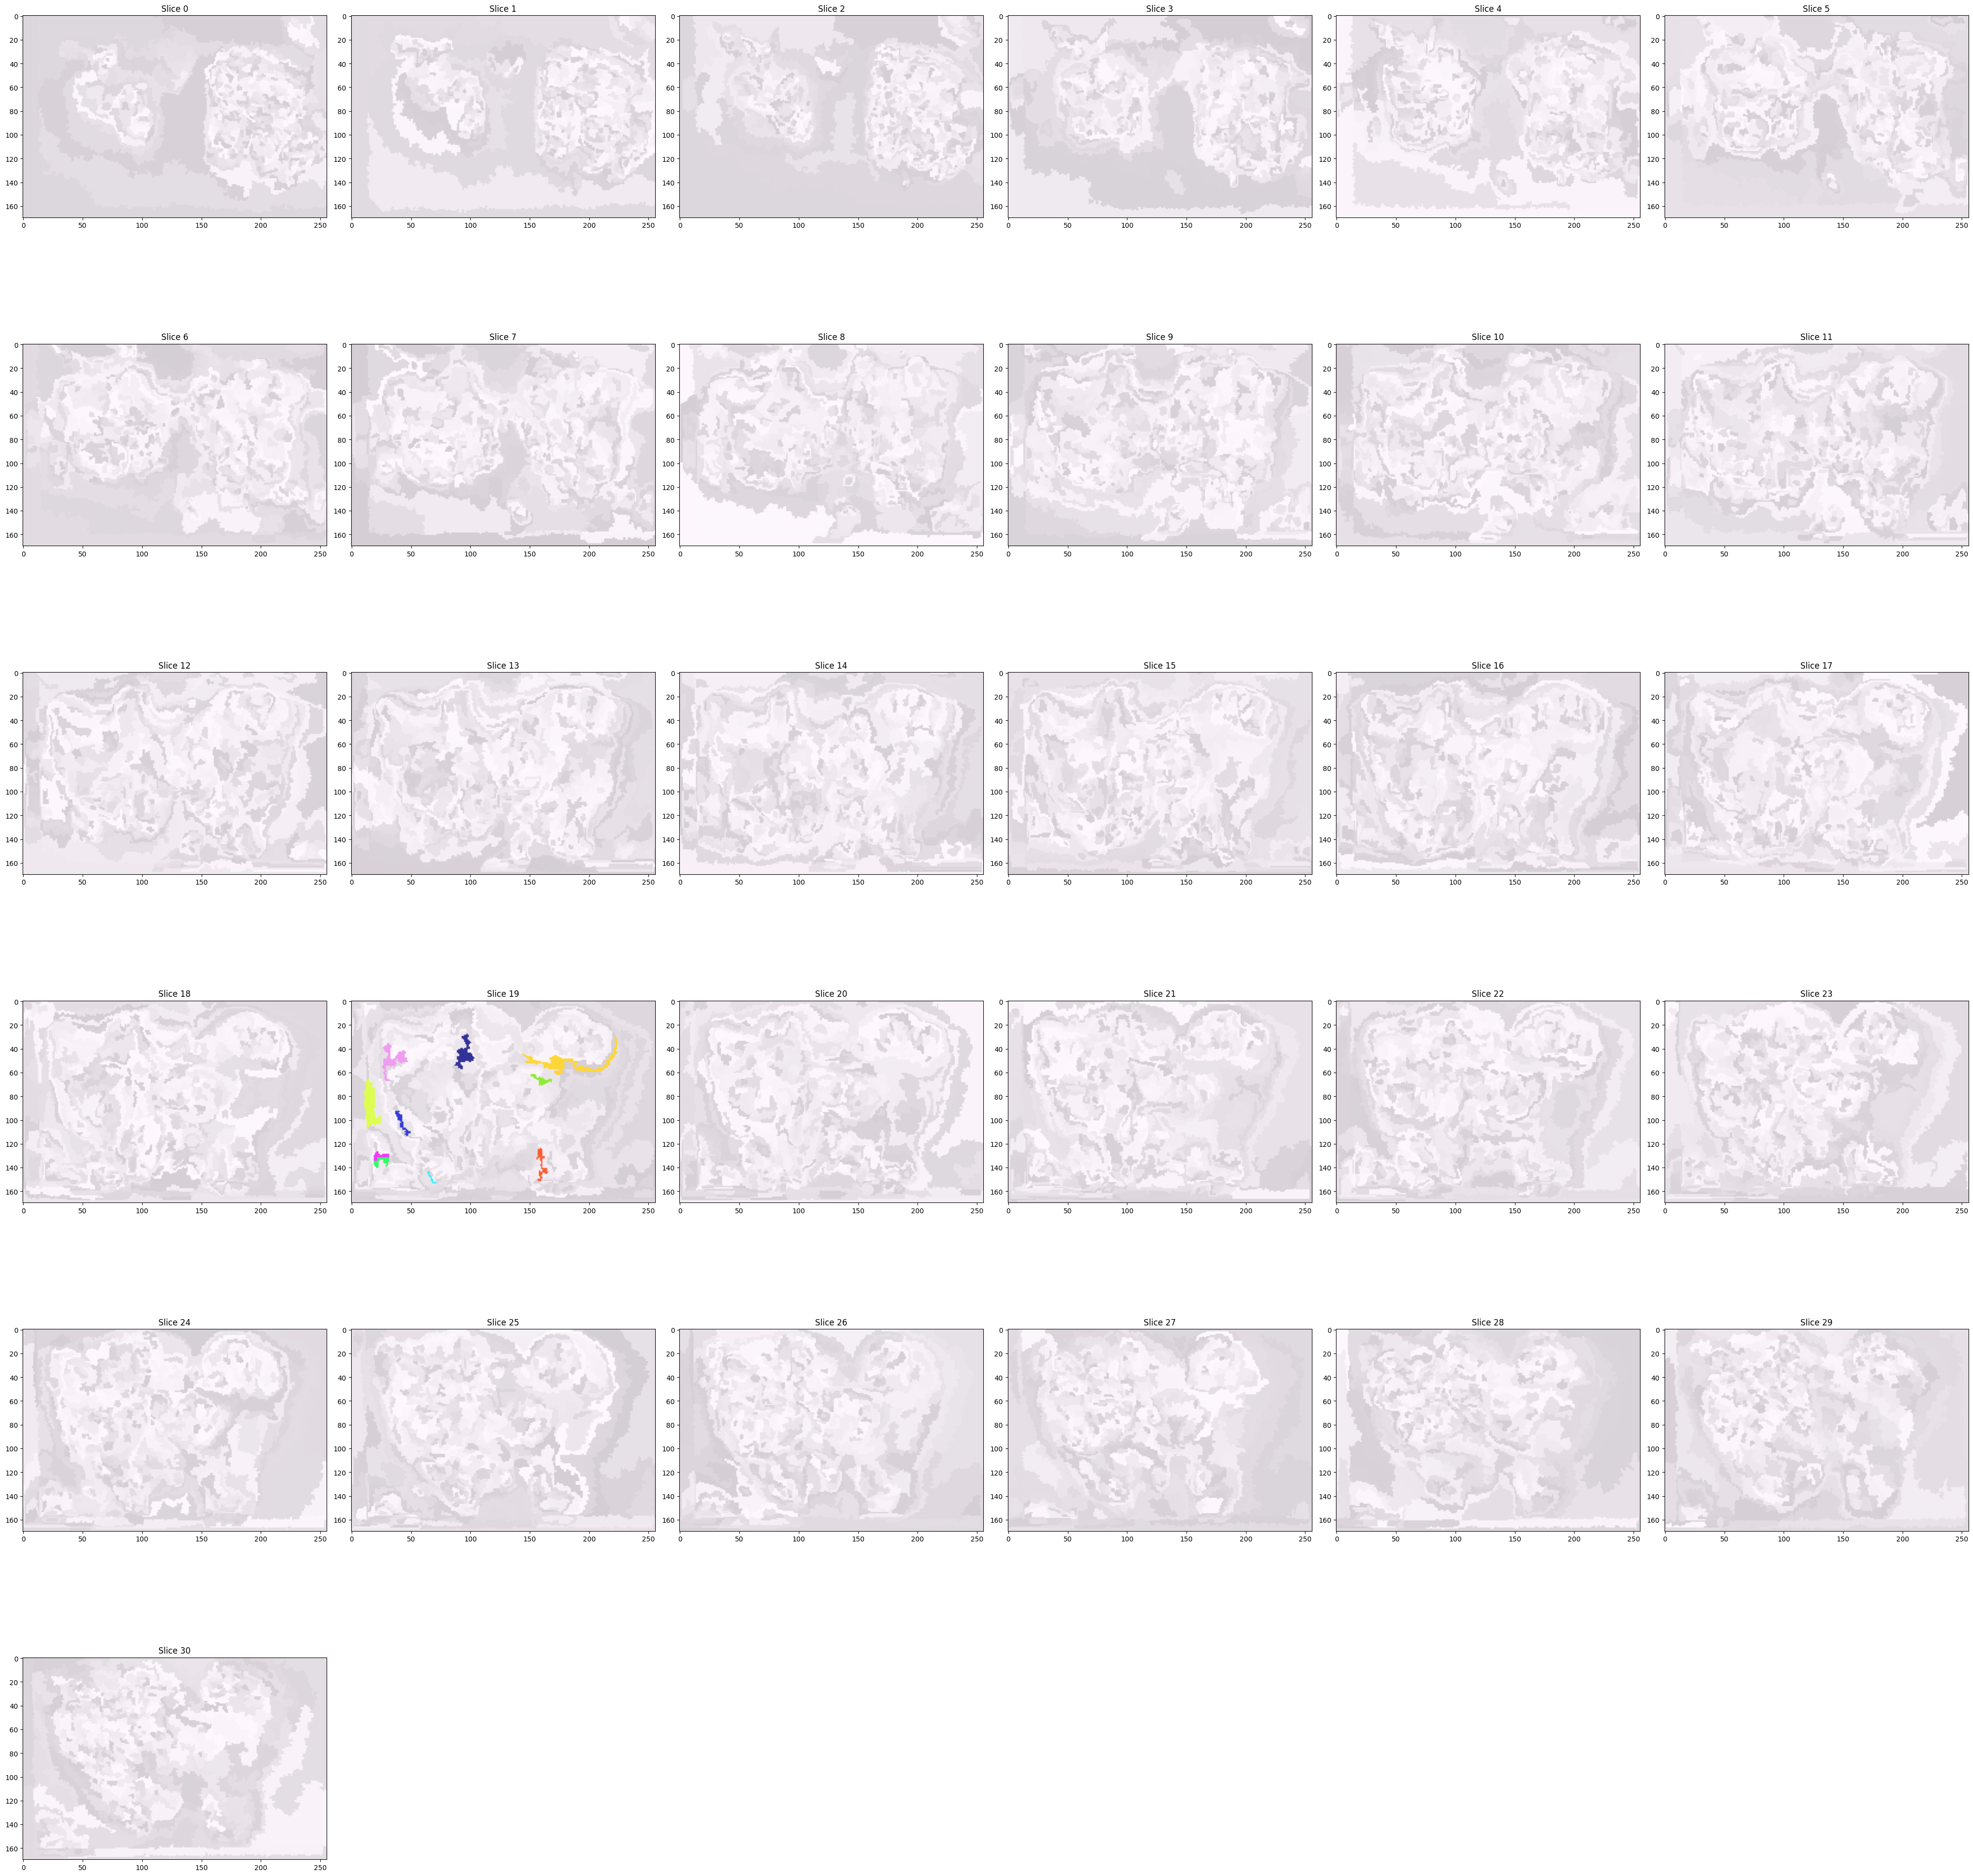

In [124]:
# given a subset of clusters
subset = [[19,0],[19,1],[19,2],[19,3],[19,4],[19,5],[19,6],[19,7],[19,8],[19,9], [19,10]]
maui_volume_time = np.reshape(scope_timestamps/1000, [signal.shape[-1],-1])
vis.plot_zscored_activity(subset, maui_volume_time,signal)

# for spatial clusters, sub in subset clusters to a blank brain
vis.plot_spatial_location(subset, cluster_labels, brain_dim)

In [7]:
# collected onset times in seconds from behavior video
times = [
'00:37',
'00:50',
'01:12',
'2:10',
'2:47',
'4:22',
'6:13',
'8:15',
'8:29',
'9:02',
'11:48',
'11:14',
'11:41',
'12:00',
'12:17',
'12:30',
'13:02',
'13:41',
'13:54',
'14:43',
    ]
# reformat strings into event times in ms
t0 = np.datetime64('2025-01-01T00:00:00')
events = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in times])
events = (events * 1000).astype('<m8[ms]')
events = t0+events
events

# organize into dataframe
# epoch_df stores all events of interest
epoch_df = pd.DataFrame(events, columns=['start'])
epoch_df['epoch'] = 'walk' # this just fills in walk into epoch column of each behavior, but should be changed for other behaviors
epoch_df['stop'] = epoch_df['start'] + np.timedelta64(1, 's')
epoch_df

,start,epoch,stop
0,2025-01-01 00:00:37,walk,2025-01-01 00:00:38
1,2025-01-01 00:00:50,walk,2025-01-01 00:00:51
2,2025-01-01 00:01:12,walk,2025-01-01 00:01:13
3,2025-01-01 00:02:10,walk,2025-01-01 00:02:11
4,2025-01-01 00:02:47,walk,2025-01-01 00:02:48
5,2025-01-01 00:04:22,walk,2025-01-01 00:04:23
6,2025-01-01 00:06:13,walk,2025-01-01 00:06:14
7,2025-01-01 00:08:15,walk,2025-01-01 00:08:16
8,2025-01-01 00:08:29,walk,2025-01-01 00:08:30
9,2025-01-01 00:09:02,walk,2025-01-01 00:09:03


In [8]:
# converting scope timestamps into datetime format
t0 = np.datetime64('2025-01-01T00:00:00')
# because scope_timestamps is for single slices, we selected the first slice of the volume to use as our timestamps
# to align to signal timestamps
deltas = np.round(scope_timestamps[::31]).astype('<m8[ms]')
timestamps = t0+deltas

In [9]:
# transform my signal array into xarray with named columns
signal_xary = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': timestamps.squeeze()},
)

In [13]:
stacked = stack_epochs(
    xary=signal_xary,
    epochs=['walk'],
    epoch_df=epoch_df,
    start_shift=np.timedelta64(1, 's'),
    end_shift=np.timedelta64(5, 's'),
    mode='start'
)

/Users/princesst/projects/maui_codebook/src/xarray_ops.py:158: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  trial_stack = xr.concat(


In [17]:
stacked

<xarray.DataArray (epoch: 1, zposs: 31, roi: 500, time: 10, trial: 20)> Size: 25MB
array([[[[[-9.64344357e-01, -1.64298913e+00, -1.71874103e+00, ...,
            5.49507542e-01,  9.34335364e-01,  3.95012325e-01],
          [-3.68153271e-01, -1.55975615e+00, -1.68921783e+00, ...,
            9.37826599e-02,  6.05235063e-01,  1.04345103e-01],
          [-2.33236395e-01, -1.71282540e+00, -1.67530400e+00, ...,
           -1.46827717e-01,  4.26679649e-01,  5.87461536e-01],
          ...,
          [-1.29578595e+00, -1.22553266e+00, -1.29031914e+00, ...,
           -1.22759936e-01,  1.13731937e+00,  1.84367431e+00],
          [-1.55817362e+00, -8.96110502e-01, -1.78365364e+00, ...,
           -1.53771521e-01,  1.17564133e+00,  1.29514749e+00],
          [            nan,             nan,             nan, ...,
            1.25113868e-01,  9.07824659e-01,  8.54469208e-01]],

         [[ 1.76630522e+00,  1.42768710e+00,  5.77507323e-01, ...,
           -5.79987751e-01, -7.31166096e-01, -7.49302964e-01],
          [ 1.86803612e+00,  1.36929039e+00,  7.26215211e-01, ...,
           -9.23499946e-03, -7.22473278e-01, -7.96729506e-01],
          [ 1.91753294e+00,  1.27713116e+00,  1.04318197e+00, ...,
            4.32359079e-01, -6.58776646e-01, -9.66556447e-01],
...
           -1.01721425e+00, -1.01721425e+00, -1.01721425e+00],
          [ 8.57696311e-01,  1.30881163e+00,  1.11677294e+00, ...,
           -1.01721425e+00, -1.01721425e+00, -1.01721425e+00],
          [            nan,             nan,             nan, ...,
           -1.01721425e+00, -1.01721425e+00, -1.01721425e+00]],

         [[ 8.18991217e-01,  4.11887182e-01,  7.07433020e-01, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00],
          [ 8.82094392e-01,  4.52016318e-01,  6.61967203e-01, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00],
          [ 8.29049734e-01,  6.08841761e-01,  4.39777817e-01, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00],
          ...,
          [ 4.13902220e-01,  5.96486174e-01,  4.43529401e-01, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00],
          [ 3.16963658e-01,  8.03413715e-01,  3.57050016e-01, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00],
          [            nan,             nan,             nan, ...,
           -1.04121733e+00, -1.04121733e+00, -1.04121733e+00]]]]],
      shape=(1, 31, 500, 10, 20))
Coordinates:
  * epoch    (epoch) object 8B 'walk'
  * time     (time) datetime64[ms] 80B 2025-01-01T00:00:01 ... 2025-01-01T00:...
  * trial    (trial) int64 160B 0 1 2 3 4 5 6 7 8 ... 11 12 13 14 15 16 17 18 19
Dimensions without coordinates: zposs, roi

In [80]:

fig = go.Figure()

for roi in range(3):
    a = stacked.sel(epoch='walk',).isel(roi=roi, zposs=19)
    # for plot_PSTH, need to be a 2d xarray
    pan = plot_PSTH(
        xarry=a,
        color=Red,
    )['data']

    fig.add_traces(pan)

# fig.add_vline(np.timedelta64(1, 's'),)
fig.show()

In [24]:
from sklearn.decomposition import PCA

In [66]:
all_clusters = np.reshape(signal, (signal.shape[0] * signal.shape[1], -1)).T
print(all_clusters.shape)
pca = PCA(n_components=10)

# fit my data to the 50 PCA components
all_transformed = pca.fit_transform(all_clusters)
# to show how much of the variance is captured in that PC component
# calculate the ratio of each component's explained variance and total explained variance (which I guess would equal 1 or 100%)
print(pca.explained_variance_ / np.sum(pca.explained_variance_)*100)

(2767, 15500)
[52.84092648 21.54886018  7.99208526  6.4791751   3.01523521  2.19360048
  2.01345659  1.75248118  1.14533397  1.01884555]


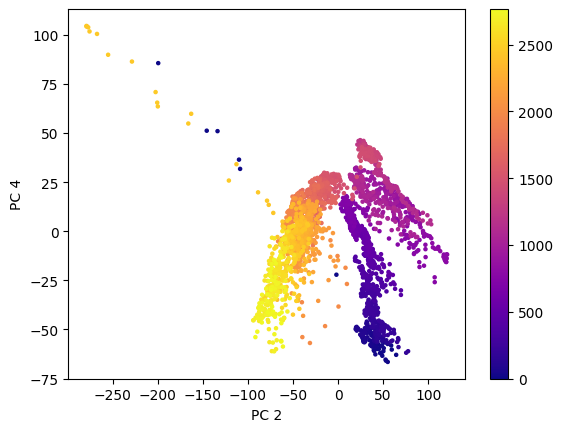

In [78]:
transformed_toplot = all_transformed.T
time = range(0, len(transformed_toplot[0]))
component_1 = 1
component_2 = 3

plt.scatter(transformed_toplot[component_1], transformed_toplot[component_2], s=5, c=time, cmap='plasma')
plt.xlabel(f'PC {component_1 + 1}')
plt.ylabel(f'PC {component_2 + 1}')
plt.colorbar()
plt.show()

(0.0, 100.0)

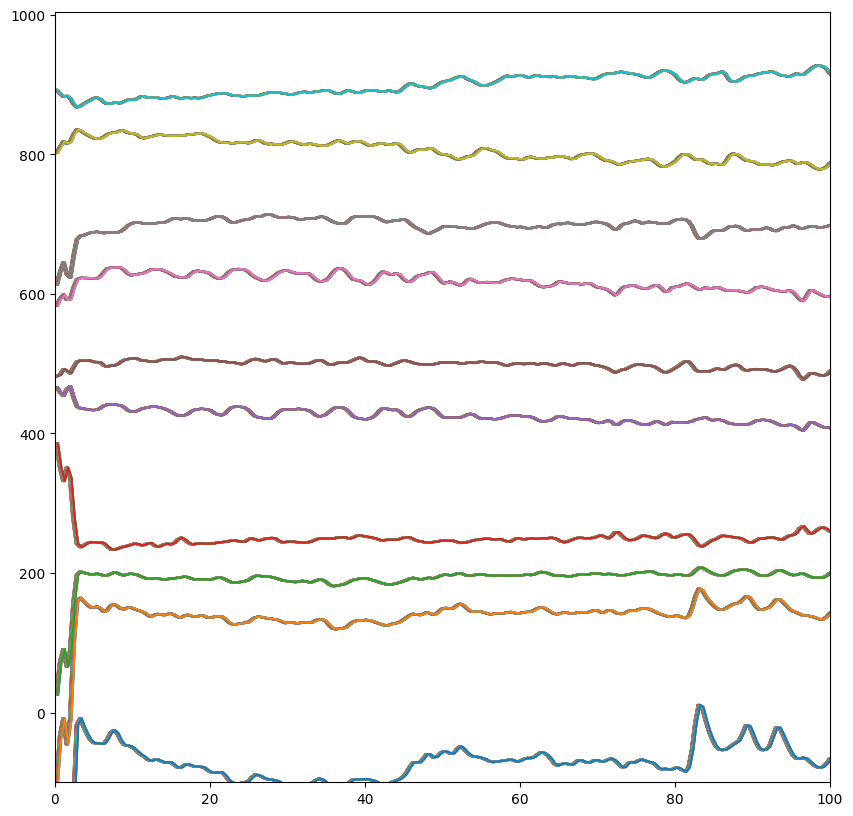

In [126]:
fig, ax = plt.subplots(figsize=(10,10))
yshift = 100
for idx, ind_cluster in enumerate(transformed_toplot):
    activity = transformed_toplot[idx]
    ax.plot(maui_volume_time, activity + (yshift*idx))
ax.set_ylim(-100)
ax.set_xlim(0, 100)



In [145]:
subset = []
for val in range(0,20):
    subset.append([20,val])

In [129]:
print(signal.shape)
print(maui_volume_time.shape)

(31, 500, 2767)
(2767, 31)


In [137]:
import seaborn as sns

(-3.0, 5.065030688448149)

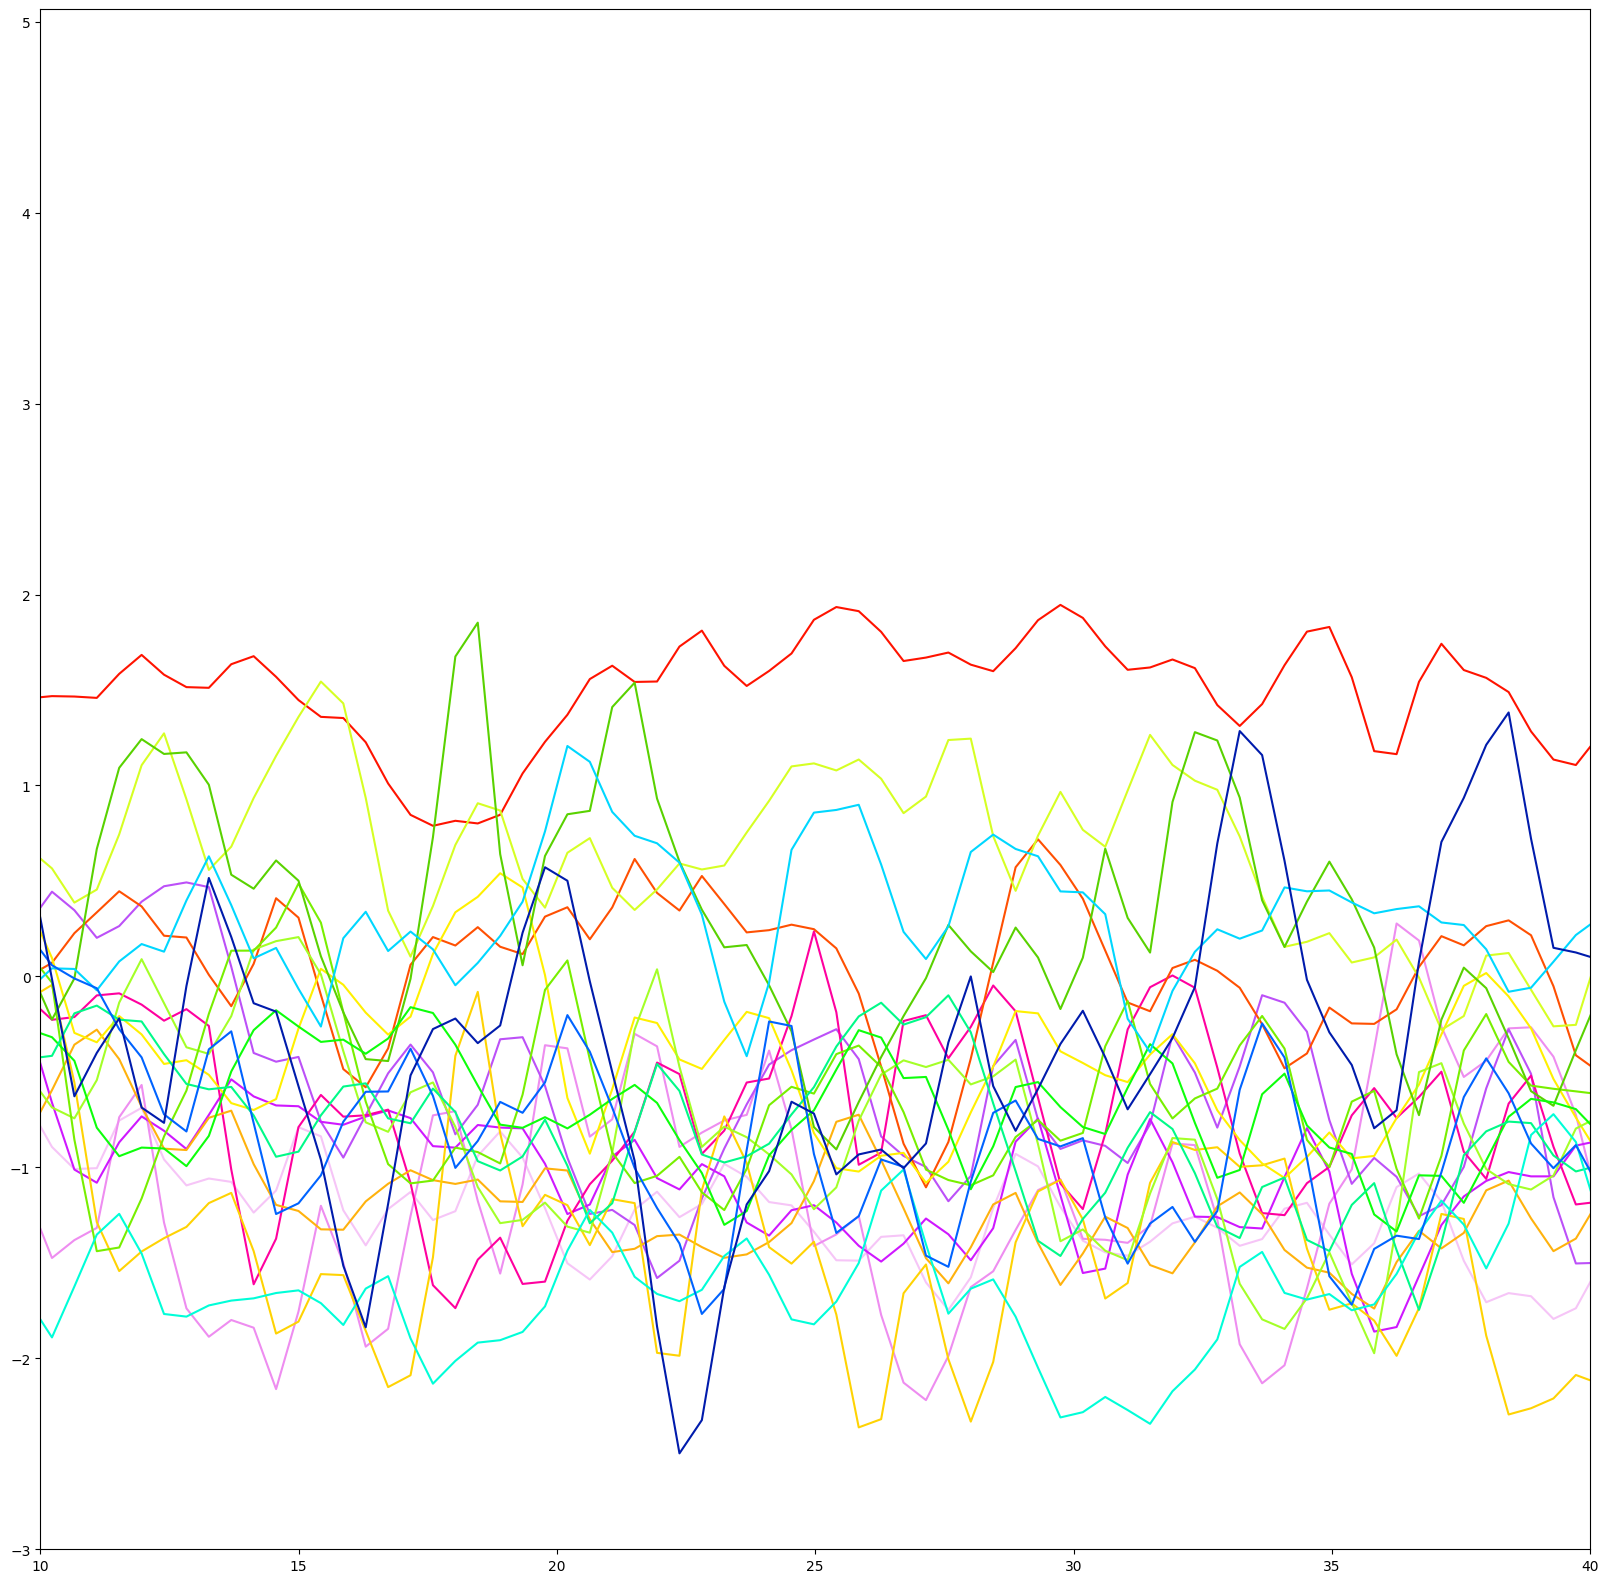

In [150]:
clusters_toplot = subset
signal_array = signal
timestamp_array = maui_volume_time


fig, ax = plt.subplots(figsize=(20,len(clusters_toplot)))
palette_colors = sns.color_palette('gist_ncar_r', len(clusters_toplot)+1)

for idx, ind_cluster in enumerate(clusters_toplot):
    activity = signal_array[ind_cluster[0],ind_cluster[1]]
    ax.plot(time, activity, color=palette_colors[idx])
time = np.mean(maui_volume_time, axis=1)

plt.xlim(10, 40)
plt.ylim(-3)

In [2]:
# plot PCs during each onset event
onsets_ms = np.asarray([int(e.split(':')[0])*60 + int(e.split(':')[1]) for e in times]*1000)
clusters_toplot = subset
signal_array = signal
timestamp_array = maui_volume_time




plt.xlim(10, 40)
plt.ylim(-3)
for idx, event in enumerate(onsets_ms):
    if idx < 3:
        fig, ax = plt.subplots(figsize=(20,len(clusters_toplot)))
        palette_colors = sns.color_palette('gist_ncar_r', len(clusters_toplot)+1)

        for idx, ind_cluster in enumerate(clusters_toplot):
            activity = signal_array[ind_cluster[0],ind_cluster[1]]
            ax.plot(time, activity, color=palette_colors[idx])
        time = np.mean(maui_volume_time, axis=1)

        plt.xlim(event-2, event+30)
        plt.ylim(-10,100)
        plt.vlines(event, ymin=0, ymax=1000)

    # vis.plot_spatial_location(subset, cluster_labels, brain_dim)

NameError: name 'np' is not defined